# Chương 4 - Phần 1: Khởi Tạo Mã Băm Wavelet Hashing

**Thông tin học viên:**
- **Họ và tên:** Nguyễn Ngọc Anh  
- **Lớp:** CN22H  
- **Môn học:** Thị giác Máy tính (Computer Vision)  

---

## 1. Import Thư Viện & Cài Đặt Ban Đầu

Import các thư viện và cấu hình cơ bản.

In [1]:
import os
import cv2
import numpy as np
import pywt
import json
import shutil
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
print("Đã import thành công các thư viện!")
print("Phiên bản PyWavelets:", pywt.__version__)
print("Phiên bản OpenCV:", cv2.__version__)

Đã import thành công các thư viện!
Phiên bản PyWavelets: 1.8.0
Phiên bản OpenCV: 4.13.0


## 2. Chuẩn Bị Dữ Liệu Kiểm Thử Quy Mô Lớn

Để đánh giá chính xác hiệu năng phân loại thống kê (vẽ đường cong ROC mịn), chúng ta xây dựng cơ sở dữ liệu gồm **205 ảnh**:
- Tải 5 ảnh gốc từ các chương trước (`anh.jpg`, `anh1.jpg`, `anh2.jpg`, `anh3.jpg` và `demo.jpg` từ Chương 3).
- Với mỗi ảnh gốc, sinh ra **40 ảnh biến thể tương tự** đại diện cho:
  - 10 mức xoay (từ -25 đến 25 độ)
  - 10 mức độ sáng (từ -50 đến 50 đơn vị)
  - 10 mức nhiễu Gaussian (với độ lệch chuẩn tăng dần)
  - 10 mức tương phản khác nhau (hệ số từ 0.5 đến 1.5)

Tổng số cặp so khớp chéo thu được sẽ là $C_{205}^2 = 20.910$ cặp ảnh, đảm bảo tính khách quan.

In [2]:
img_dir = "../data/input"
os.makedirs(img_dir, exist_ok=True)

# 1. Sao chép demo.jpg từ Chương 3 nếu chưa có trong thư mục input
ch3_demo_path = "../../chapter03_edge_detection/data/input/demo.jpg"
target_demo_path = os.path.join(img_dir, "demo.jpg")
if os.path.exists(ch3_demo_path) and not os.path.exists(target_demo_path):
    shutil.copy(ch3_demo_path, target_demo_path)

# 2. Khai báo 5 ảnh gốc làm nền tảng
base_images = ["anh.jpg", "anh1.jpg", "anh2.jpg", "anh3.jpg", "demo.jpg"]

# 3. Tạo thư mục variants để chứa các biến thể ảnh
var_dir = os.path.join(img_dir, "variants")
os.makedirs(var_dir, exist_ok=True)

image_paths = {}
metadata = []

for idx, base_name in enumerate(base_images):
    base_path = os.path.join(img_dir, base_name)
    if not os.path.exists(base_path):
        continue
    
    img_bgr = cv2.imread(base_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = img_gray.shape
    
    # Lưu ảnh gốc chính làm biến thể số 0
    name = f"base_{idx}_var_0"
    out_path = os.path.join(var_dir, f"{name}.jpg")
    cv2.imwrite(out_path, img_gray)
    image_paths[name] = out_path
    metadata.append({"name": name, "group": idx})
    
    var_count = 1
    
    # 1. Tạo 10 ảnh xoay (xoay các góc từ -25 đến 25 độ, bước nhảy 5)
    for angle in [-25, -20, -15, -10, -5, 5, 10, 15, 20, 25]:
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img_rotated = cv2.warpAffine(img_gray, M, (w, h))
        name = f"base_{idx}_var_{var_count}"
        out_path = os.path.join(var_dir, f"{name}.jpg")
        cv2.imwrite(out_path, img_rotated)
        image_paths[name] = out_path
        metadata.append({"name": name, "group": idx})
        var_count += 1
        
    # 2. Tạo 10 ảnh sáng (tăng giảm độ sáng từ -50 đến 50 đơn vị)
    for val in [-50, -40, -30, -20, -10, 10, 20, 30, 40, 50]:
        img_bright = np.clip(img_gray.astype(np.int16) + val, 0, 255).astype(np.uint8)
        name = f"base_{idx}_var_{var_count}"
        out_path = os.path.join(var_dir, f"{name}.jpg")
        cv2.imwrite(out_path, img_bright)
        image_paths[name] = out_path
        metadata.append({"name": name, "group": idx})
        var_count += 1
        
    # 3. Tạo 10 ảnh bị nhiễu Gaussian (độ lệch chuẩn std tăng dần từ 3 đến 30)
    for std in [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]:
        noise = np.random.normal(0, std, img_gray.shape).astype(np.int16)
        img_noisy = np.clip(img_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        name = f"base_{idx}_var_{var_count}"
        out_path = os.path.join(var_dir, f"{name}.jpg")
        cv2.imwrite(out_path, img_noisy)
        image_paths[name] = out_path
        metadata.append({"name": name, "group": idx})
        var_count += 1
        
    # 4. Tạo 10 ảnh tương phản (nhân hệ số tương phản từ 0.5 đến 1.5)
    for factor in [0.5, 0.6, 0.7, 0.8, 0.9, 1.1, 1.2, 1.3, 1.4, 1.5]:
        img_contrast = np.clip(img_gray.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        name = f"base_{idx}_var_{var_count}"
        out_path = os.path.join(var_dir, f"{name}.jpg")
        cv2.imwrite(out_path, img_contrast)
        image_paths[name] = out_path
        metadata.append({"name": name, "group": idx})
        var_count += 1

print(f"Đã chuẩn bị xong dữ liệu: {len(image_paths)} ảnh đầu vào.")

Đã chuẩn bị xong dữ liệu: 205 ảnh đầu vào.


### Trực Quan Hóa Một Số Ảnh Mẫu Từ 5 Nhóm Gốc

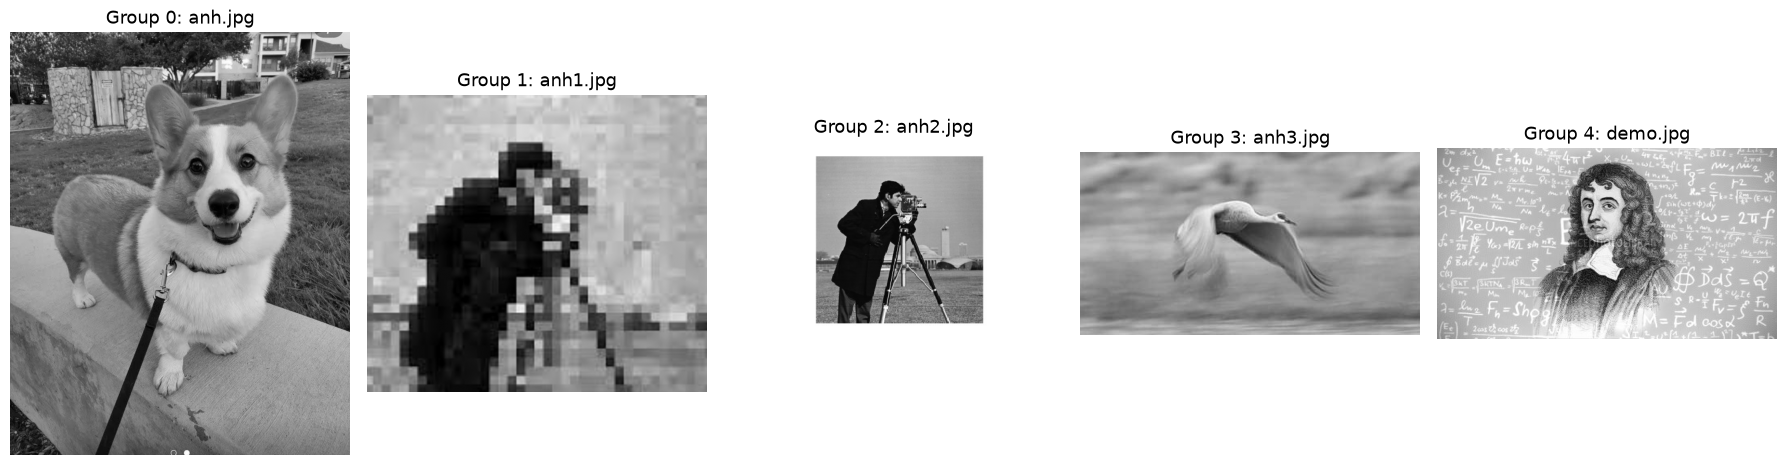

In [3]:
# Hiển thị 5 ảnh gốc chính đại diện cho 5 lớp cấu trúc
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for idx, base_name in enumerate(base_images):
    img_path = os.path.join(img_dir, base_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Group {idx}: {base_name}")
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

## 3. Định Nghĩa Thuật Toán Băm Wavelet Hashing

Chúng ta cài đặt cả phương pháp băm thô (Slide) và phương pháp băm nhận thức chuẩn (Standard wHash).

In [4]:
def custom_quantize(c, step=2):
    if isinstance(c, tuple):
        return tuple(custom_quantize(sub_c, step) for sub_c in c)
    elif isinstance(c, np.ndarray):
        return np.round(c / step).astype(np.int64)
    else:
        return int(np.round(c / step))

def flatten_coeffs(coeffs):
    flat = []
    for c in coeffs:
        if isinstance(c, tuple):
            for sub_c in c: flat.append(sub_c.flatten())
        else:
            flat.append(c.flatten())
    return np.concatenate(flat)

def wavelet_hash_slide(image_path, wavelet='db4', level=1, step=2, size=(64, 64)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img_resized = cv2.resize(img, size)
    coeffs = pywt.wavedec2(img_resized.astype(np.float32), wavelet, level=level)
    coeffs_quant = [custom_quantize(c, step) for c in coeffs]
    flattened = flatten_coeffs(coeffs_quant)
    return [int(bit % 2) for bit in flattened]

def wavelet_hash_standard(image_path, wavelet='db4', level=1, size=(64, 64)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img_resized = cv2.resize(img, size)
    coeffs = pywt.wavedec2(img_resized.astype(np.float32), wavelet, level=level)
    cA = coeffs[0]
    med = np.median(cA)
    return (cA > med).astype(int).flatten().tolist()

print("Đã định nghĩa các thuật toán băm Wavelet.")

Đã định nghĩa các thuật toán băm Wavelet.


## 4. Tính Khoảng Cách Hamming So Khớp Chéo Lớn

Tính khoảng cách nhị phân giữa các mã băm ảnh. Phép tính được tối ưu bằng NumPy để tăng tốc tối đa.

In [5]:
def hamming_distance(hash1, hash2):
    # Tối ưu hóa bằng NumPy (vectorization) thay thế vòng lặp Python
    return int(np.sum(np.abs(np.array(hash1) - np.array(hash2))))

image_keys = list(image_paths.keys())

# Trích xuất mã băm trước cho toàn bộ ảnh
hashes_slide = {name: wavelet_hash_slide(path) for name, path in image_paths.items()}
hashes_std = {name: wavelet_hash_standard(path) for name, path in image_paths.items()}

pairs_results = []
print("Đang thực hiện so khớp chéo 20.910 cặp ảnh...")

for i in range(len(image_keys)):
    for j in range(i + 1, len(image_keys)):
        name1, name2 = image_keys[i], image_keys[j]
        
        # Cùng nhóm gốc (cùng idx của base_images) -> Tương tự
        group1 = metadata[i]["group"]
        group2 = metadata[j]["group"]
        is_similar = 1 if group1 == group2 else 0
        
        dist_slide = hamming_distance(hashes_slide[name1], hashes_slide[name2])
        dist_std = hamming_distance(hashes_std[name1], hashes_std[name2])
        
        pairs_results.append({
            "pair": [name1, name2],
            "gt": is_similar,
            "dist_slide": dist_slide,
            "dist_std": dist_std
        })

print(f"Đã tính toán xong khoảng cách Hamming cho {len(pairs_results)} cặp ảnh.")

# Hiển thị 15 cặp ảnh đầu tiên làm ví dụ mẫu
print(f"\n{'-'*95}")
print(f"{'Cặp Ảnh':<45} | {'Ground Truth':<12} | {'Khoảng Cách Slide':<15} | {'Khoảng Cách wHash Chuẩn':<15}")
print(f"{'-'*95}")
for item in pairs_results[:15]:
    n1, n2 = item["pair"]
    gt_lbl = "Tương tự" if item["gt"] == 1 else "Khác biệt"
    print(f"{n1 + ' vs ' + n2:<45} | {gt_lbl:<12} | {item['dist_slide']:<15} | {item['dist_std']:<15}")
print(f"{'-'*95}")

# Lưu trữ kết quả sang JSON
data_out_dir = "../data/processed"
os.makedirs(data_out_dir, exist_ok=True)
with open(os.path.join(data_out_dir, "pairs_results.json"), "w") as f:
    json.dump({
        "max_len_slide": len(hashes_slide["base_0_var_0"]),
        "max_len_std": len(hashes_std["base_0_var_0"]),
        "results": pairs_results
    }, f, indent=1)
print("Đã lưu kết quả phân tích sang data/processed/pairs_results.json!")

Đang thực hiện so khớp chéo 20.910 cặp ảnh...
Đã tính toán xong khoảng cách Hamming cho 20910 cặp ảnh.

-----------------------------------------------------------------------------------------------
Cặp Ảnh                                       | Ground Truth | Khoảng Cách Slide | Khoảng Cách wHash Chuẩn
-----------------------------------------------------------------------------------------------
base_0_var_0 vs base_0_var_1                  | Tương tự     | 2457            | 540            
base_0_var_0 vs base_0_var_2                  | Tương tự     | 2451            | 466            
base_0_var_0 vs base_0_var_3                  | Tương tự     | 2496            | 414            
base_0_var_0 vs base_0_var_4                  | Tương tự     | 2449            | 378            
base_0_var_0 vs base_0_var_5                  | Tương tự     | 2417            | 262            
base_0_var_0 vs base_0_var_6                  | Tương tự     | 2420            | 238            
base_0_var_0 vs